# Задание 1. Алгоритм Дейкстры



In [1]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def _to_adjacency(graph):
    """Унифицирует вход. На выходе всегда dict[node -> list[(neighbor, weight)]].

    Поддерживает два формата:
      * матрица смежности: list[list[number]] (квадратная). 0 / None / inf = нет ребра.
      * словарь смежности: dict[node -> list[(neighbor, weight)]].
    """
    if isinstance(graph, dict):
        adj = {u: list(nbrs) for u, nbrs in graph.items()}
        # Подстраховка: гарантируем, что у каждой упомянутой вершины есть запись в adj.
        for u, nbrs in graph.items():
            for v, _ in nbrs:
                adj.setdefault(v, [])
        return adj

    # Иначе считаем, что это матрица смежности.
    n = len(graph)
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            w = graph[i][j]
            if w is None or w == 0 or w == math.inf:
                continue  # ребра нет
            adj[i].append((j, w))
    return adj


def dijkstra(graph, start):
    """Кратчайшие пути из start ко всем остальным вершинам.

    Возвращает (dist, prev):
      dist[v] — длина кратчайшего пути start->v (math.inf если недостижима);
      prev[v] — предшественник v на кратчайшем пути (для восстановления).
    """
    adj = _to_adjacency(graph)

    # 1) Инициализация массивов.
    dist = {v: math.inf for v in adj}
    prev = {v: None for v in adj}
    dist[start] = 0

    # 2) Мин-куча. Храним (текущее расстояние, вершина).
    #    Не удаляем устаревшие записи руками: при извлечении просто пропустим их.
    pq = [(0, start)]

    while pq:
        d, u = heapq.heappop(pq)

        # 3) Устаревшая запись — мы уже нашли путь короче. Пропускаем.
        if d > dist[u]:
            continue

        # 4) Релаксация исходящих рёбер.
        for v, w in adj[u]:
            if w < 0:
                raise ValueError(
                    f"Дейкстра не работает с отрицательными весами (ребро {u}->{v} имеет вес {w})."
                )
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))

    return dist, prev


def reconstruct_path(prev, start, target):
    """По словарю prev восстанавливает путь start -> target. [] если пути нет."""
    if target not in prev:
        return []
    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        if cur == start:
            break
        cur = prev[cur]
    if not path or path[-1] != start:
        return []
    return list(reversed(path))

## Пример 1: матрица смежности

Маленький граф из 5 вершин. Ноль означает «ребра нет».

In [3]:
INF = 0  # удобно: нули в матрице = отсутствие ребра
matrix = [
    # 0  1  2  3  4
    [ 0, 7, 9, 0, 0],   # из 0
    [ 7, 0,10,15, 0],   # из 1
    [ 9,10, 0,11, 2],   # из 2
    [ 0,15,11, 0, 6],   # из 3
    [ 0, 0, 2, 6, 0],   # из 4
]

dist, prev = dijkstra(matrix, start=0)
print('Длины кратчайших путей из вершины 0:')
for v, d in sorted(dist.items()):
    print(f'  0 -> {v}: {d}   путь: {reconstruct_path(prev, 0, v)}')

Длины кратчайших путей из вершины 0:
  0 -> 0: 0   путь: [0]
  0 -> 1: 7   путь: [0, 1]
  0 -> 2: 9   путь: [0, 2]
  0 -> 3: 17   путь: [0, 2, 4, 3]
  0 -> 4: 11   путь: [0, 2, 4]


## Пример 2: словарь смежности

Тот же граф, но заданный как `dict[node -> list[(neighbor, weight)]]`.

In [4]:
adj = {
    0: [(1, 7), (2, 9)],
    1: [(0, 7), (2, 10), (3, 15)],
    2: [(0, 9), (1, 10), (3, 11), (4, 2)],
    3: [(1, 15), (2, 11), (4, 6)],
    4: [(2, 2), (3, 6)],
}

dist, prev = dijkstra(adj, start=0)
for v, d in sorted(dist.items()):
    print(f'0 -> {v}: dist={d}, путь={reconstruct_path(prev, 0, v)}')

0 -> 0: dist=0, путь=[0]
0 -> 1: dist=7, путь=[0, 1]
0 -> 2: dist=9, путь=[0, 2]
0 -> 3: dist=17, путь=[0, 2, 4, 3]
0 -> 4: dist=11, путь=[0, 2, 4]


## Сверка с NetworkX

Проверяем, что наша реализация выдаёт ровно те же длины, что встроенная в NetworkX.

In [5]:
G = nx.Graph()
for u, nbrs in adj.items():
    for v, w in nbrs:
        if u < v:  # чтобы не дублировать рёбра
            G.add_edge(u, v, weight=w)

ref = nx.single_source_dijkstra_path_length(G, 0)
ours, _ = dijkstra(adj, 0)

print('NetworkX:', dict(sorted(ref.items())))
print('Наш    :', dict(sorted(ours.items())))
assert ref == ours, 'Расхождение!'
print('OK — результаты совпадают.')

NetworkX: {0: 0, 1: 7, 2: 9, 3: 17, 4: 11}
Наш    : {0: 0, 1: 7, 2: 9, 3: 17, 4: 11}
OK — результаты совпадают.


## Визуализация графа и одного из кратчайших путей

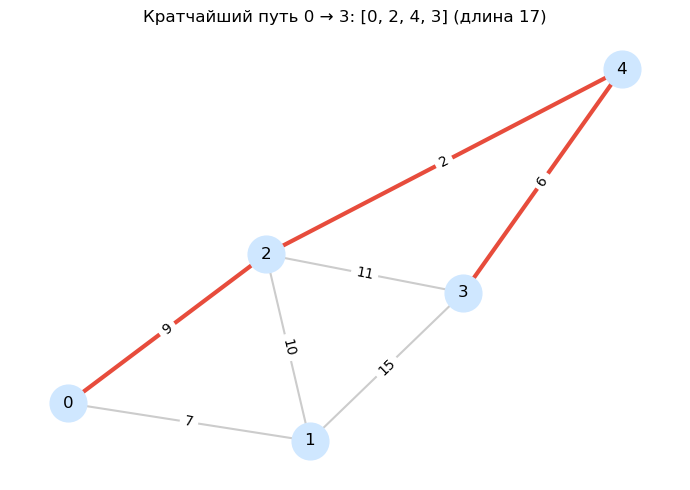

In [6]:
target = 3
dist, prev = dijkstra(adj, 0)
path = reconstruct_path(prev, 0, target)
path_edges = list(zip(path, path[1:]))

pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx_nodes(G, pos, node_color='#cfe7ff', node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#cccccc', width=1.5, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#e74c3c', width=3, ax=ax)
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
ax.set_title(f'Кратчайший путь 0 → {target}: {path} (длина {dist[target]})')
ax.set_axis_off()
plt.tight_layout()
plt.show()